In [9]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from Tracer.windfield import WindField
from scipy.interpolate import interp1d
import joblib
import scipy.stats as stats

# Data inspection

In [10]:
ds = xr.open_dataset("windfield_z_100m.nc")

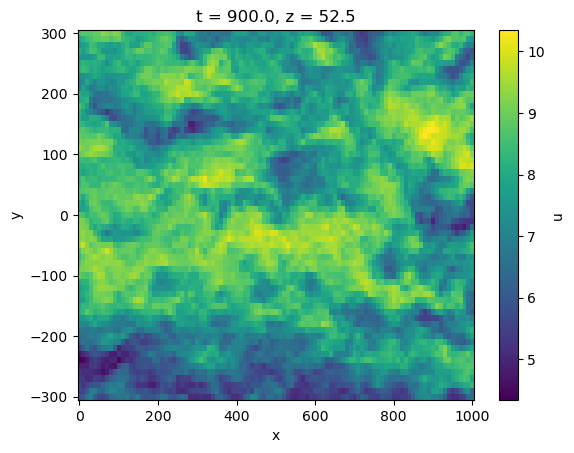

In [11]:
ds.isel(t=900,z=5)['u'].plot(x="x", y="y", cmap="viridis")

In [12]:
# Compute the mean profile over space for every single second
u_t = ds.u.mean(dim=['x', 'y'])  # Shape: (t, z)
v_t = ds.v.mean(dim=['x', 'y'])  # Shape: (t, z)
w_t = ds.w.mean(dim=['x', 'y'])  # Shape: (t, z)

u_x = ds.u.mean(dim=['t', 'y'])  # Shape: (x, z)
v_x = ds.v.mean(dim=['t', 'y'])  # Shape: (x, z)
w_x = ds.w.mean(dim=['t', 'y'])  # Shape: (x, z)

u_y = ds.u.mean(dim=['t', 'x'])  # Shape: (y, z)
v_y = ds.v.mean(dim=['t', 'x'])  # Shape: (y, z)
w_y = ds.w.mean(dim=['t', 'x'])  # Shape: (y, z)

The flow does not seem to be stationary. Espescially in y where there seems to be a speed up later on.

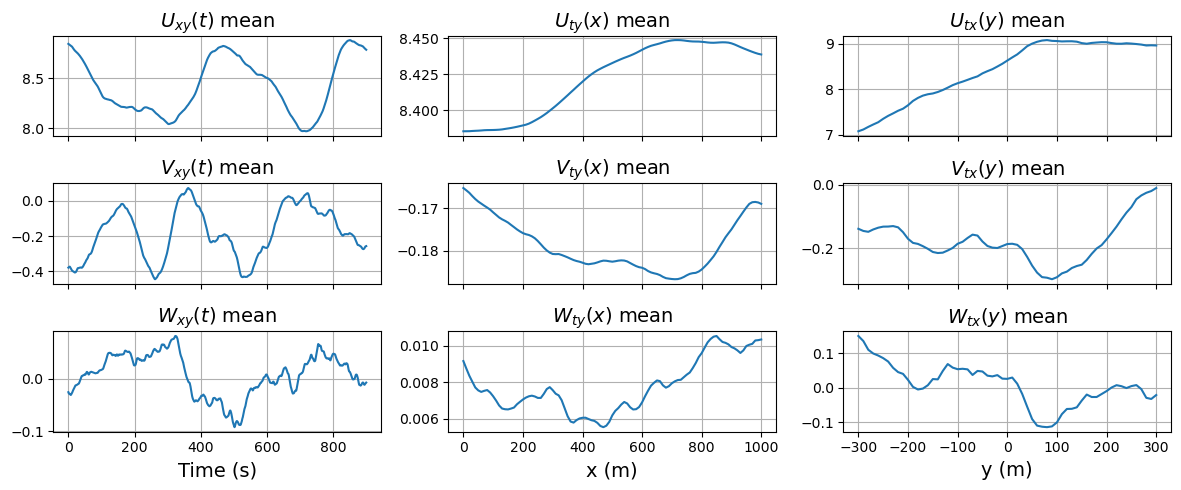

In [13]:
fig, ax = plt.subplots(3,3,figsize=(12, 5), sharex='col')
# Plot the evolution at your lowest grid point (2.5m) and highest grid point (102.5m)
ax[0,0].plot(ds.t, u_t.isel(z=-1), label='$U_{xy}(t)$ mean')
ax[1,0].plot(ds.t, v_t.isel(z=-1), label='$V_{xy}(t)$ mean')
ax[2,0].plot(ds.t, w_t.isel(z=-1), label='$W_{xy}(t)$ mean')
ax[2,0].set_xlabel('Time (s)', fontsize=14)

ax[0,1].plot(ds.x, u_x.isel(z=-1), label='$U_{ty}(x)$ mean')
ax[1,1].plot(ds.x, v_x.isel(z=-1), label='$V_{ty}(x)$ mean')
ax[2,1].plot(ds.x, w_x.isel(z=-1), label='$W_{ty}(x)$ mean')
ax[2,1].set_xlabel('x (m)', fontsize=14)

ax[0,2].plot(ds.y, u_y.isel(z=-1), label='$U_{tx}(y)$ mean')
ax[1,2].plot(ds.y, v_y.isel(z=-1), label='$V_{tx}(y)$ mean')
ax[2,2].plot(ds.y, w_y.isel(z=-1), label='$W_{tx}(y)$ mean')
ax[2,2].set_xlabel('y (m)', fontsize=14)

for i in range(3):
    for j in range(3):
        ax[i,j].set_title(ax[i,j].legend().get_texts()[0].get_text(), fontsize=14)
        ax[i,j].legend().remove()
        ax[i,j].grid(True)

#plt.suptitle('Spatial and Temporal Evolution of Mean Velocity at Height z=102.5m')
plt.tight_layout()
plt.show()

Here it is clearly seen how the mean velocity in y increases

# Creation of POD library

In [45]:
# Create a visualization of the energy distribution of the pod modes 
# and find the number of modes required to capture a certain percentage of the energy.
def plot_pod_energy(S, threshold=0.8):
    # Calculate Eigenvalues (Energy)
    lambdas = S**2
    
    # Calculate Individual and Cumulative Energy Fraction
    energy_fraction = lambdas / np.sum(lambdas)
    cumulative_energy = np.cumsum(energy_fraction)
    
    # Find the index where we cross the threshold
    n_required = np.argmax(cumulative_energy >= threshold) + 1
    
    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Individual Energy (Bar Chart)
    ax1.plot(range(1, len(energy_fraction) + 1), energy_fraction, c=plt.cm.coolwarm(0.1), marker='o', linestyle='-', label='Energy Fraction')
    ax1.set_xlabel('Mode Number', fontsize=14)
    ax1.set_ylabel('Energy Fraction $(\\gamma_i)$', fontsize=14)
    
    # Cumulative Energy (Step/Line Chart)
    ax2 = ax1.twinx()
    ax2.step(range(1, len(cumulative_energy) + 1), cumulative_energy, where='mid', color=plt.cm.coolwarm(0.9), label='Cumulative Energy')
    ax2.axhline(y=threshold, color='0', linestyle='--', label=f'{n_required} Modes Required for {int(threshold*100)}% Threshold')
    ax2.axvline(x=n_required, color='0', linestyle='--')
    ax2.set_ylabel('Cumulative Energy Fraction', fontsize=14)
    plt.legend(loc='center right', fontsize=14)
    #plt.title(f'POD Energy Spectrum (Modes for {int(threshold*100)}% Energy: {n_required})')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.show()
    
    return n_required


In [15]:
# Main function to create the POD library from the LES dataset
def create_pod_library(ds, threshold=0.9):
    """
    Decomposes LES wind data into a unscaled POD modes.
    
    Returns:
        A dictionary containing callable interpolators for modes and coefficients,
        plus eigenvalues for TKE scaling in the solver.
    """
    # Prepare Dimensions
    n_t, n_x, n_y, n_z = len(ds.t), len(ds.x), len(ds.y), len(ds.z)
    z_coords = ds.z.values

    # Calculate the mean profile
    u_mean = ds.u.mean(dim=['t', 'x', 'y'])
    v_mean = ds.v.mean(dim=['t', 'x', 'y'])
    w_mean = ds.w.mean(dim=['t', 'x', 'y'])

    # Center the data
    u_prime = (ds.u - u_mean).stack(samples=('t', 'x', 'y')).values
    v_prime = (ds.v - v_mean).stack(samples=('t', 'x', 'y')).values
    w_prime = (ds.w - w_mean).stack(samples=('t', 'x', 'y')).values

    k_les = (np.mean(u_prime**2) + np.mean(v_prime**2) + np.mean(w_prime**2)) / 2
    print(f"Estimated TKE from fluctuations: {k_les:.4f}")

    
    # Combined snapshot matrix X: (3*z, samples)
    X = np.vstack([u_prime, v_prime, w_prime])

    # SVD -> Compute the singular value decomposition
    U, S, Vh = np.linalg.svd(X, full_matrices=False)

    # Determine number of modes based on energy threshold
    n_modes = plot_pod_energy(S, threshold=threshold)

    # Scale and Reshape Spatial Modes (U/Phi)
    # Explicitly split components from U: (3*z, n_modes)
    # Rows 0:n_z -> u component, n_z:2*n_z -> v component, 2*n_z:3*n_z -> w component
    U_modes = U[0:n_z, :n_modes]           # (n_z, n_modes)
    V_modes = U[n_z:2*n_z, :n_modes]      # (n_z, n_modes)
    W_modes = U[2*n_z:3*n_z, :n_modes]    # (n_z, n_modes)
    

    # Stack components into modes_array: (n_modes, n_z, 3)
    # This represents the vertical 'shape' of the gusts for each component
    modes_array = np.stack([U_modes.T, V_modes.T, W_modes.T], axis=2)  # (n_modes, n_z, 3)

    # # Scale modes by n_modes for proper normalization (optional, depending on convention)
    # modes_array *= np.sqrt(n_modes)  # Scale modes for proper normalization (optional)

    # Scale and Reshape Temporal/Spatial Coefficients (a)
    # multiply by singular values for proper scaling of the modes
    coeffs = Vh[:n_modes, :] * S[:n_modes, np.newaxis]  # (n_modes, samples)
    
    # Create interpolation function for modes
    modes_func = interp1d(z_coords, modes_array, axis=1, bounds_error=False, fill_value="extrapolate")

    # Calculate Eigenvalues (Energy) for TKE scaling
    eigenvalues = S**2 / (n_t*n_x*n_y - 1)

    squared_modes_sum = U_modes**2 + V_modes**2 + W_modes**2

    # Multiply each mode column by its respective eigenvalue, then sum across modes
    print("Equivalent TKE captured by modes:", 0.5 * np.sum(squared_modes_sum * eigenvalues[:n_modes], axis=1))

    # Package of the POD Library for external use
    pod_lib = {
        'Phi': modes_func,           # Callable z -> modes, direction
        'C': eigenvalues/k_les,                # TKE fraction for each mode
        'z': z_coords
    }

    # Package of the Statistical Library for analysis or reconstruction
    stat_lib = {
        'coeffs': coeffs,              # Temporal coefficients for reconstruction
        'eigenvalues': eigenvalues,     # Energy of each mode for scaling
        'samples': n_t*n_x*n_y             # Original sample indices for reference
    }
    
    # Save the libraries for future use
    joblib.dump(pod_lib, 'pod_library.joblib', compress=3)
    joblib.dump(stat_lib, 'stat_library.joblib', compress=3)
    return pod_lib, stat_lib

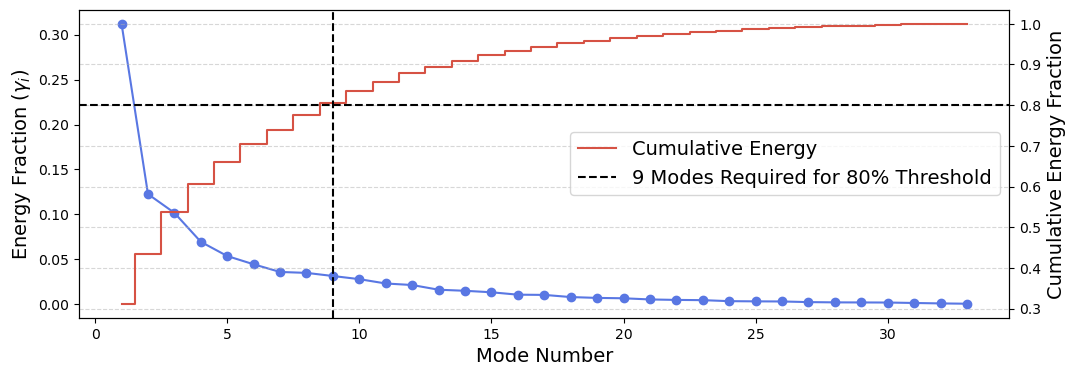

POD and stat library loaded from file.


In [46]:
# avoid running the SVD if the data is already processed and saved in a library
try:
    pod_lib = joblib.load('pod_library.joblib')
    stat_lib = joblib.load('stat_library.joblib')
    plot_pod_energy(np.sqrt(stat_lib['eigenvalues']), threshold=0.8)
    print("POD and stat library loaded from file.")
except FileNotFoundError:
    print("File not found. Creating new POD library.")
    # chosen slice at y=200 to capture the developed flow as seen in the inspection
    pod_lib, stat_lib = create_pod_library(ds.sel(y=slice(200, 200)), threshold=0.8) # 40 mb

# Analysis

Let us take a look at the 9 first modes

In [28]:
plt.cm.seismic([0.0,0.4,0.6])

array([[0. , 0. , 0.3, 1. ],
       [0.6, 0.6, 1. , 1. ],
       [1. , 0.6, 0.6, 1. ]])

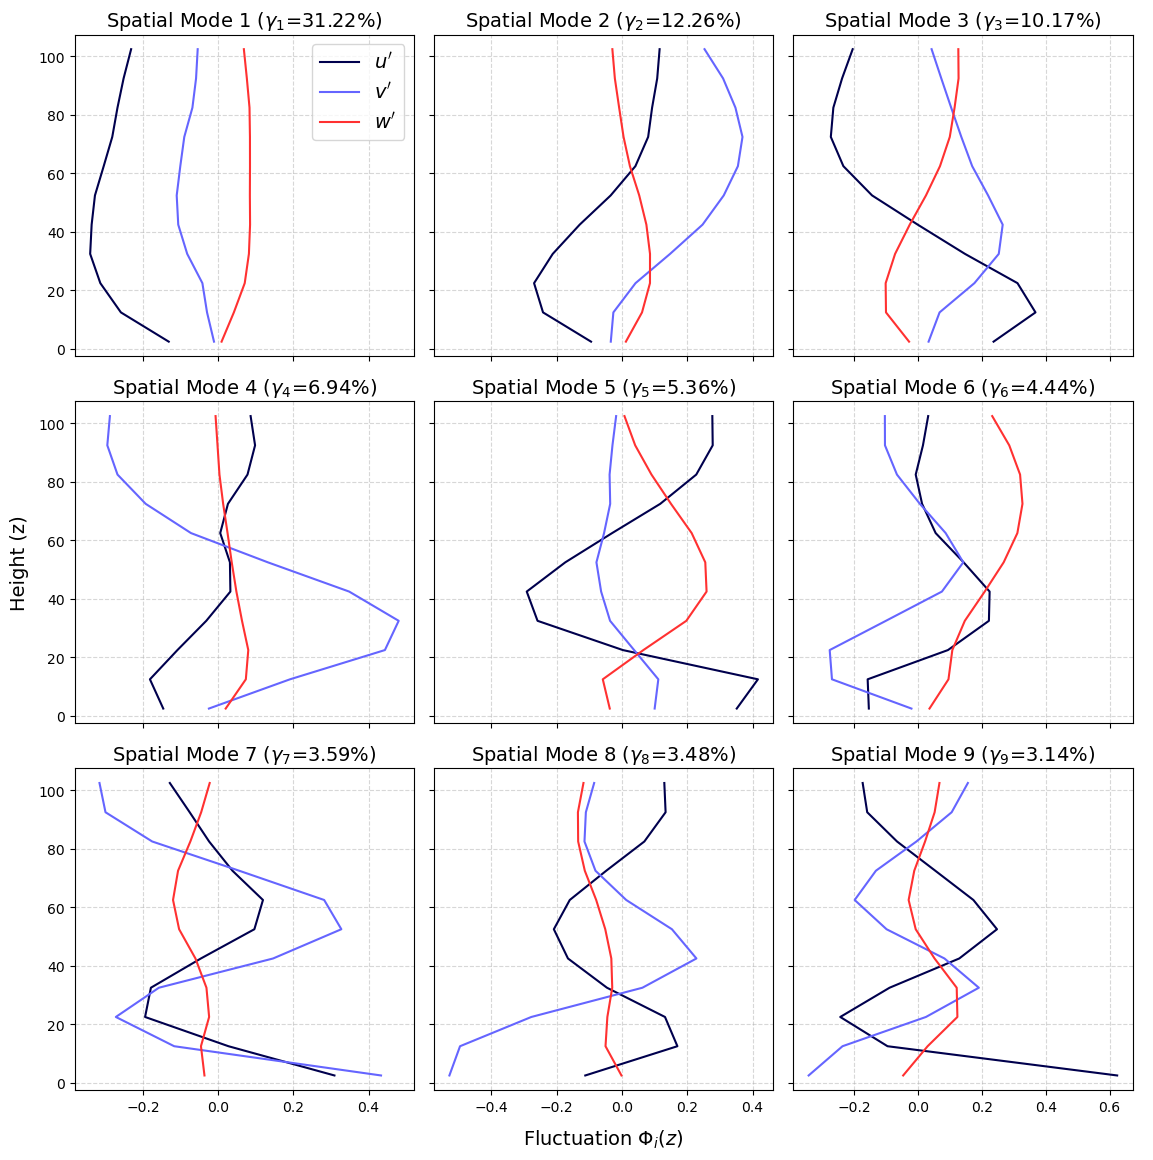

In [44]:
# import the libraries and visualize the first 9 modes with their energy contribution
phi = pod_lib['Phi']
z_coords = pod_lib['z']
eig = stat_lib['eigenvalues']
dis = eig / np.sum(eig)
fig, ax = plt.subplots(3, 3, figsize=(12, 12), sharex='col', sharey=True)

colors = plt.cm.coolwarm([])

for m in range(9):
    for i, comp in enumerate(['u', 'v', 'w']):
        ax[m//3, m%3].plot(phi(z_coords)[m, :, i], z_coords, label=f'${comp}\'$', color=plt.cm.seismic([0.0, 0.35, 0.7])[i])
        ax[m//3, m%3].set_title(f'Spatial Mode {m+1} ($\\gamma_{m+1}$={dis[m]*100:.2f}%)', fontsize=14)
        ax[m//3, m%3].grid(True, which='both', linestyle='--', alpha=0.5)

        #plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
ax[0,0].legend(loc='upper right', fontsize=14)

fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Fluctuation $\\Phi_i(z)$", labelpad=10, fontsize=14)
plt.ylabel("Height (z)", labelpad=10, fontsize=14)

plt.tight_layout()
plt.show()

First mode seems to primarily be a "drift" mode that corrects a spatial or temporal change in average velocity.

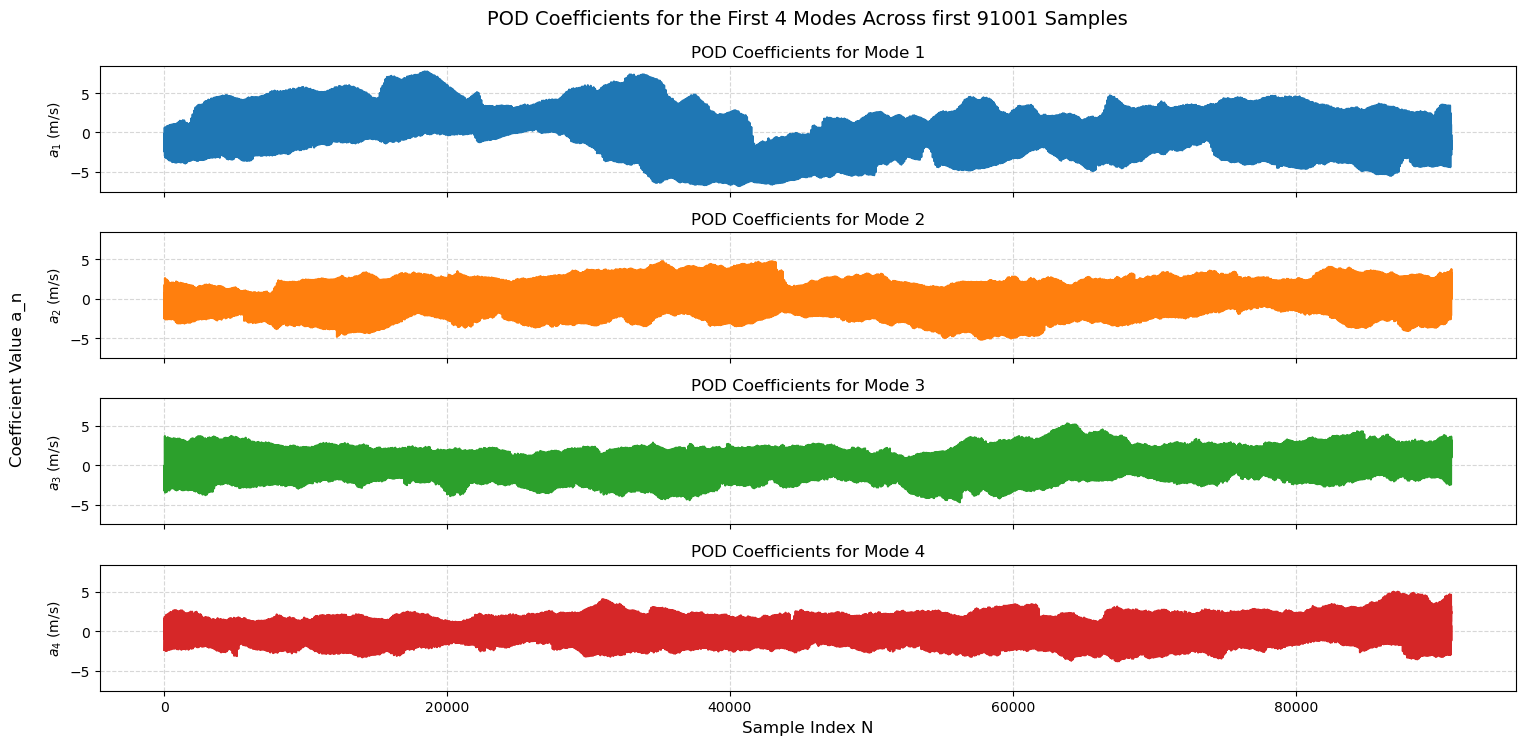

In [11]:
a = stat_lib['coeffs']

fig, ax = plt.subplots(4,1,figsize=(16, 8), sharex=True, sharey=True)

plot_start = 0 # len(samples) // 2  # Start plotting from the middle of the sample range
plot_n =  a.shape[1] # 400
for m in range(0,4,1): # Loop over the first 5 modes
    ax[m].plot(range(plot_start, plot_start + plot_n, 1), a[m][plot_start:plot_start + plot_n], color=f'C{m}')
    ax[m].set_title(f'POD Coefficients for Mode {m+1}')
    ax[m].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[m].set_ylabel(fr'$a_{m+1}$ (m/s)')

# add a big invisible axis for the overall title and labels
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.title(f'POD Coefficients for the First 4 Modes Across first {plot_n} Samples', fontsize=14, pad=30)
plt.xlabel("Sample Index N", fontsize=12)
plt.ylabel("Coefficient Value a_n", labelpad=30, fontsize=12)
plt.tight_layout()
plt.show()

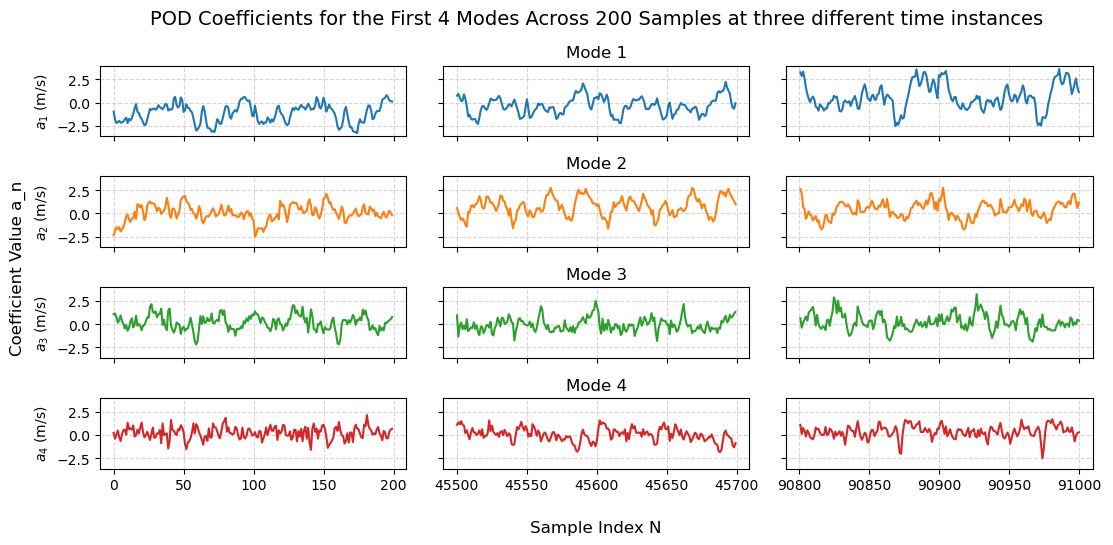

In [12]:
a = stat_lib['coeffs']

fig, ax = plt.subplots(4,3,figsize=(12, 6), sharey=True, sharex='col')

n = a.shape[1]
plot_n = 200
shifts = [0, n//2, n-plot_n] # Shift starting points for each mode to visualize different parts of the sample space
for m, shift in enumerate(shifts*4): # Loop over the first 5 modes
    ax[m//3, m%3].plot(range(shift, shift + plot_n, 1), a[m][shift:shift + plot_n], color=f'C{m//3}')
    ax[m//3, 1].set_title(f'Mode {m//3+1}')
    ax[m//3, m%3].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[m//3, 0].set_ylabel(fr'$a_{m//3+1}$ (m/s)')

# add a big invisible axis for the overall title and labels
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axis
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.title(f'POD Coefficients for the First 4 Modes Across {plot_n} Samples at three different time instances', fontsize=14, pad=30)
plt.xlabel("Sample Index N", labelpad=20, fontsize=12)
plt.ylabel("Coefficient Value a_n", labelpad=30, fontsize=12)
plt.tight_layout()
plt.show()

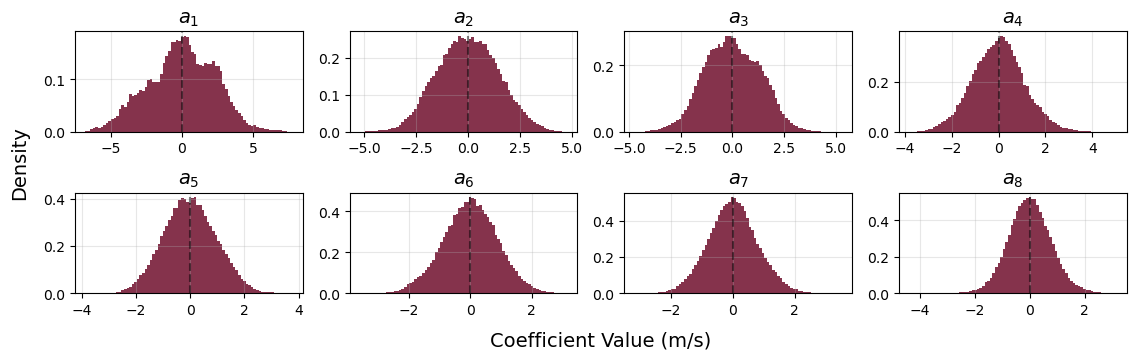

In [53]:
fig, axs = plt.subplots(2, 4, figsize=(12, 4), sharex=False, sharey=False)
a = stat_lib['coeffs']

color = plt.cm.RdBu([0.0, 1.0])

for m in range(8):

    data = a[m]
    
    # Plot fordelingen
    axs[m//4, m%4].hist(data, bins=80, density=True, alpha=0.8, color=color[0])
    axs[m//4, m%4].axvline(0, color='black', linestyle='--', alpha=0.5) # center at 0
    axs[m//4, m%4].set_title(f'$a_{m+1}$', fontsize=14)
    axs[m//4, m%4].grid(alpha=0.3)
    
#plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Coefficient Value (m/s)", labelpad=10, fontsize=14)
plt.ylabel("Density", labelpad=10, fontsize=14)
plt.tight_layout()
plt.show()

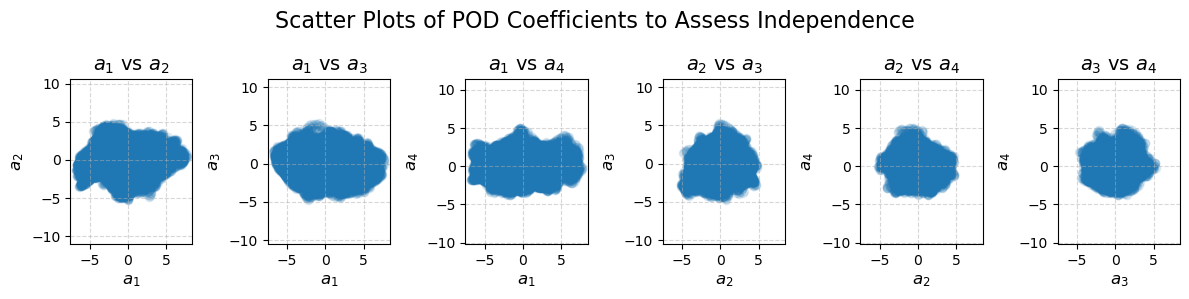

In [14]:
# check indepence of the coefficients by plotting them against each other in a scatter plot
fig, ax = plt.subplots(1,6, figsize=(12,3), sharex='row')

# make 3x3 plot with a1 vs a2, a1 vs a3, a2 vs a3 etc
for i, (j, k) in enumerate([(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]):
    
    ax[i].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[i].scatter(a[j], a[k], alpha=0.1)
    ax[i].set_xlabel(f'$a_{j+1}$', fontsize=12)
    ax[i].set_ylabel(f'$a_{k+1}$', fontsize=12)
    ax[i].set_title(f'$a_{j+1}$ vs $a_{k+1}$', fontsize=14)
    ax[i].axis('equal')

plt.suptitle('Scatter Plots of POD Coefficients to Assess Independence', fontsize=16)
plt.tight_layout()
plt.show()

Here they seem quite independent. There is no clear trend of dependency between the different modes. 

**$a_2$ vs $a_4$ does look a bit like a pentagon

In [15]:
ref = u_t.mean(dim=['t']).isel(z=3)
ref.z.values, ref.values
samples = stat_lib['samples']

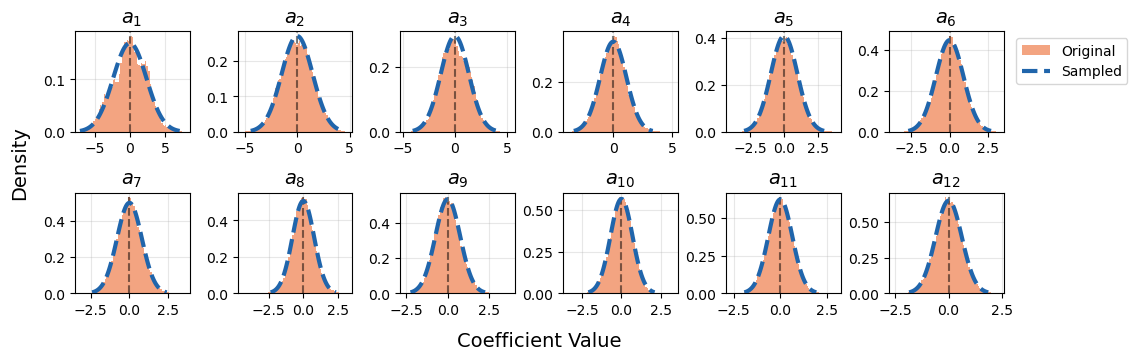

In [102]:
fig, axs = plt.subplots(2, 6, figsize=(12, 4), sharex=False, sharey=False)


data = [np.random.normal(loc=0, scale=sig, size=samples) for sig in stat_lib['eigenvalues']**.5]
data_unscaled = data / S[:, np.newaxis]

sigma = stat_lib['eigenvalues']**.5

for m in range(12):
    
    # Plot fordelingen
    axs[m//6, m%6].hist(a[m], bins=80, density=True, alpha=1, color=plt.cm.RdBu([0.3]), zorder=2, label='Original')
    x = np.linspace(-3*sigma[m], 3*sigma[m], 100)
    axs[m//6, m%6].plot(x, stats.norm.pdf(x, loc=0, scale=sigma[m]), color=plt.cm.RdBu([0.9]), linestyle='--', linewidth=3, zorder=4, label='Sampled')
    # axs[m//6, m%6].hist(data[m], bins=40, density=True, alpha=0.4, color="yellow", edgecolor='black', linewidth=0.4, zorder=3, label='Sampled')
    axs[m//6, m%6].axvline(0, color='black', linestyle='--', alpha=0.5) # center at 0
    axs[m//6, m%6].set_title('$a_{' + str(m+1) + '}$', fontsize=14)
    axs[m//6, m%6].grid(alpha=0.3)

    axs[m//6, m%6].grid(alpha=0.3)
axs[0, 5].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Coefficient Value", labelpad=10, fontsize=14)
plt.ylabel("Density", labelpad=10, fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
rans_file = '../RANS/nc files/flowdata_z0_0.03_mb_cartesian.nc'
WindField('rans', ds=rans_file, U_ref=ref.values, z_ref=ref.z.values).ds.sel(x=0,y=0, z=ref.z.values, method='nearest').tke.values

array(1.28863391)

In [18]:
tke_ref = 1.28863391

print(stat_lib['eigenvalues']**.5)
g = pod_lib['gamma']
print(np.sqrt(2/3 * 0.889 * g * 30))
np.isclose(np.sqrt(2/3 * 0.889 * g * 30), stat_lib['eigenvalues'][:14]**.5)

[2.35859575 1.47784646 1.3459881  1.11234016 0.97722872 0.88957186
 0.79956695 0.78796835 0.74776343 0.70461176 0.64084957 0.61660869
 0.53572759 0.51560739 0.48607732 0.43436606 0.42928258 0.37604545
 0.3531386  0.34238857 0.30678159 0.2911969  0.28300132 0.24527474
 0.23723141 0.23238779 0.20349757 0.19003868 0.18595671 0.18156952
 0.15510767 0.12382659 0.09637436]
[2.35610231 1.47628412 1.34456516 1.11116422 0.97619562 0.88863143
 0.79872168 0.78713534 0.74697292 0.70386687 0.64017208 0.61595683
 0.53516124 0.5150623 ]


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False])

In [19]:
tke_ref = 1.28863391
gamma = pod_lib['gamma']
a_les = [np.random.normal(loc=0, scale=sig, size=samples) for sig in stat_lib['eigenvalues'][:4]**.5]
a_tke = [np.random.normal(loc=0, scale=3*np.sqrt(g*tke_ref), size=samples) for g in gamma[:4]]

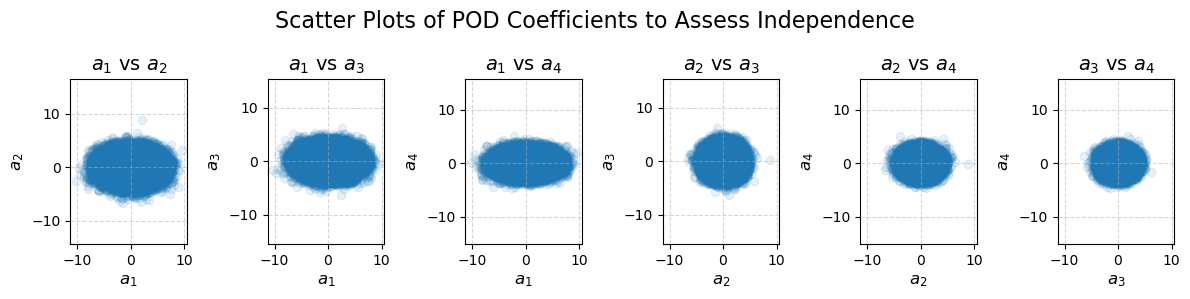

In [20]:
# check indepence of the coefficients by plotting them against each other in a scatter plot
fig, ax = plt.subplots(1,6, figsize=(12,3), sharex='row')

# make 3x3 plot with a1 vs a2, a1 vs a3, a2 vs a3 etc
for i, (j, k) in enumerate([(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]):
    
    ax[i].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[i].scatter(a_les[j], a_les[k], alpha=0.1)
    ax[i].set_xlabel(f'$a_{j+1}$', fontsize=12)
    ax[i].set_ylabel(f'$a_{k+1}$', fontsize=12)
    ax[i].set_title(f'$a_{j+1}$ vs $a_{k+1}$', fontsize=14)
    ax[i].axis('equal')

plt.suptitle('Scatter Plots of POD Coefficients to Assess Independence', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
k_les = 0.8099

21.999818107405538


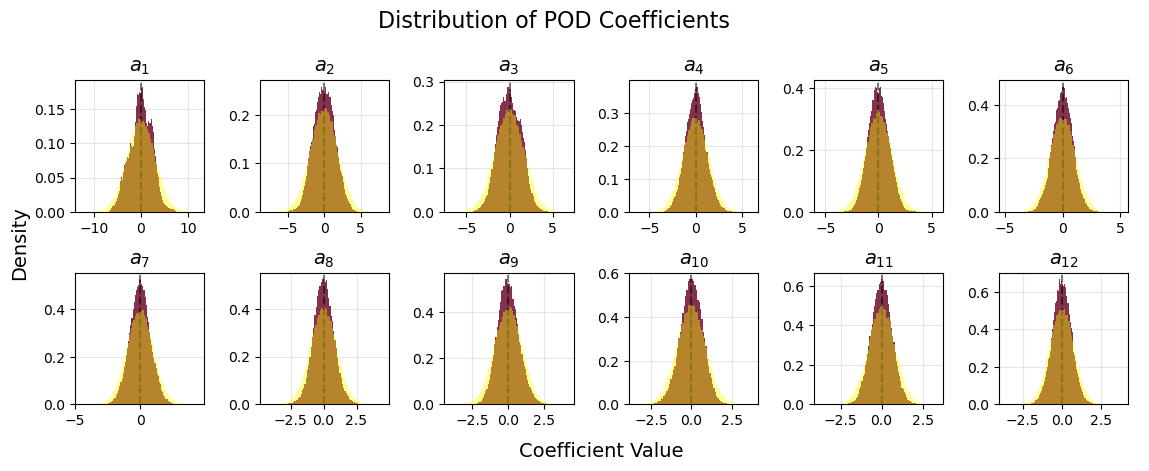

In [69]:
fig, axs = plt.subplots(2, 6, figsize=(12, 5), sharex=False, sharey=False)

tke_les_30 = [0.67076341,0.86044756,0.86462353,0.8715744,0.84140872,0.75295266,0.72029975,0.67504408,0.63233014,0.63549155,0.57600496]
k_ref = 1.28863391
color = plt.cm.RdBu([0.0, 1.0])

Cs = pod_lib['C']

data = [np.random.normal(loc=0, scale=np.sqrt(c*k_ref), size=stat_lib['samples']) for c in Cs]

for m in range(12):
    
    # Plot fordelingen
    axs[m//6, m%6].hist(a[m], bins=80, density=True, alpha=0.8, color=color[0], zorder=2)
    axs[m//6, m%6].hist(data[m], bins=80, density=True, alpha=0.4, color="yellow", zorder=3)
    axs[m//6, m%6].axvline(0, color='black', linestyle='--', alpha=0.5) # center at 0
    axs[m//6, m%6].set_title('$a_{' + str(m+1) + '}$', fontsize=14)
    axs[m//6, m%6].grid(alpha=0.3)

    axs[m//6, m%6].grid(alpha=0.3)
#plt.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
fig.suptitle('Distribution of POD Coefficients', fontsize=16)
fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
plt.xlabel("Coefficient Value", labelpad=10, fontsize=14)
plt.ylabel("Density", labelpad=10, fontsize=14)
plt.tight_layout()
plt.show()

# Reconstruction Example

In [23]:
def plot_scaled_pod(pod_lib, n_modes, wind: WindField, ax=None):
    tke_rans = wind.ds.tke.values
    z_coords = wind.ds.z.values

    phi = pod_lib['modes']
    gamma = pod_lib['gamma'][:n_modes]

    # Draw standard normal random variables (variance = 1.0) for each mode.
    # This keeps the coefficients pristine until we apply the exact target scaling.
    ran = np.random.normal(loc=0.0, scale=1.0, size=n_modes)

    prime = np.zeros((3, len(tke_rans)))

    for i, z in enumerate(z_coords):
        # Compute the exact physical standard deviation vector for all modes at this height
        # Shape: (n_modes,)
        sigma_target = np.sqrt(2.0 * tke_rans[i] * gamma) # tke at z for n modes
        
        # Scale the random coefficients to their physical target (N(0, sigma_target^2))
        # Shape: (n_modes,)
        a_local = ran * sigma_target
        
        # Reconstruct the velocity components smoothly
        if n_modes == 1:
            raw_prime = a_local[0] * phi(z)[0] # single mode is just a scalar times the mode shape
        else:
            raw_prime = a_local @ phi(z)[:n_modes] # multile modes are a linear combination of the mode shapes
            
        prime[:, i] = raw_prime
        
    if ax is None:
        ax = plt.gca()

    u = wind.ds.U.values + prime[0]
    v = wind.ds.V.values + prime[1]
    w = wind.ds.W.values + prime[2]

    ax.plot(u, wind.ds.z.values, label='U with POD Fluctuations for {0} modes'.format(n_modes))
    ax.set_xlabel('Wind Speed (m/s)')
    ax.set_ylabel('Height (m)')

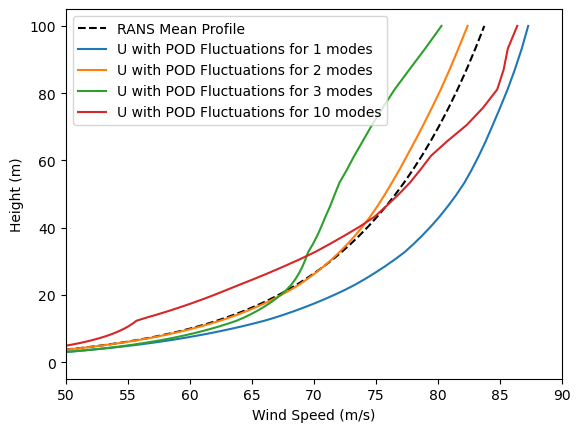

In [24]:
w = WindField(U_ref=60, z_ref=10)
plt.plot(w.ds.U.values, w.ds.z.values, label='RANS Mean Profile', color='k', linestyle='--')
plot_scaled_pod(pod_lib, n_modes=1, wind=w)
plot_scaled_pod(pod_lib, n_modes=2, wind=w)
plot_scaled_pod(pod_lib, n_modes=3, wind=w)
plot_scaled_pod(pod_lib, n_modes=10, wind=w)
plt.xlim(50,90)
plt.legend()